In [ ]:
import os
import sys

project_root = "/root/work/tvm-ansor"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build-release"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build-release")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build-release:" + os.environ.get("LD_LIBRARY_PATH", "")


import tvm

TARGET = tvm.target.Target("cuda")


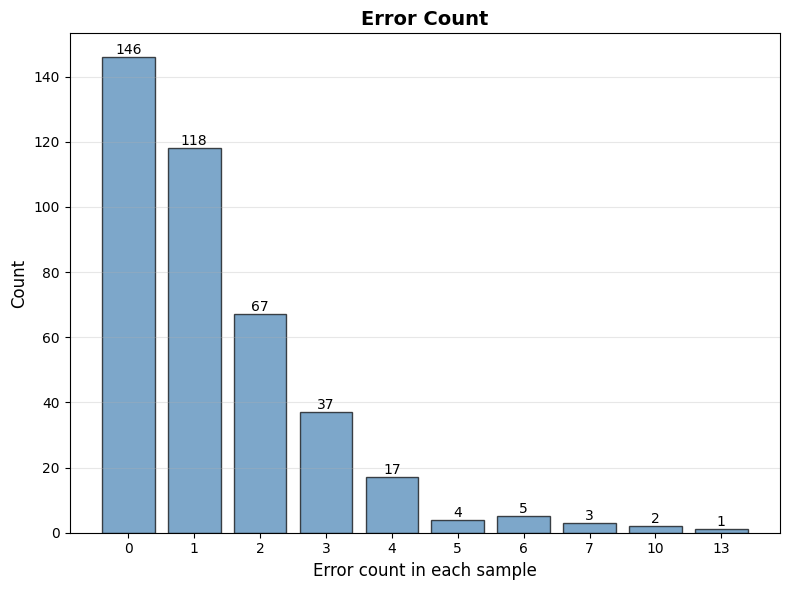

In [25]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    "0": 146,
    "1": 118,
    "2": 67,
    "3": 37,
    "4": 17,
    "5": 4,
    "6": 5,
    "7": 3,
    "10": 2,
    "13": 1
}

# 데이터 준비
keys = list(data.keys())
values = list(data.values())

# 히스토그램 그리기
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(keys, values, color='steelblue', edgecolor='black', alpha=0.7)

# 각 바 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Error count in each sample', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Error Count', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

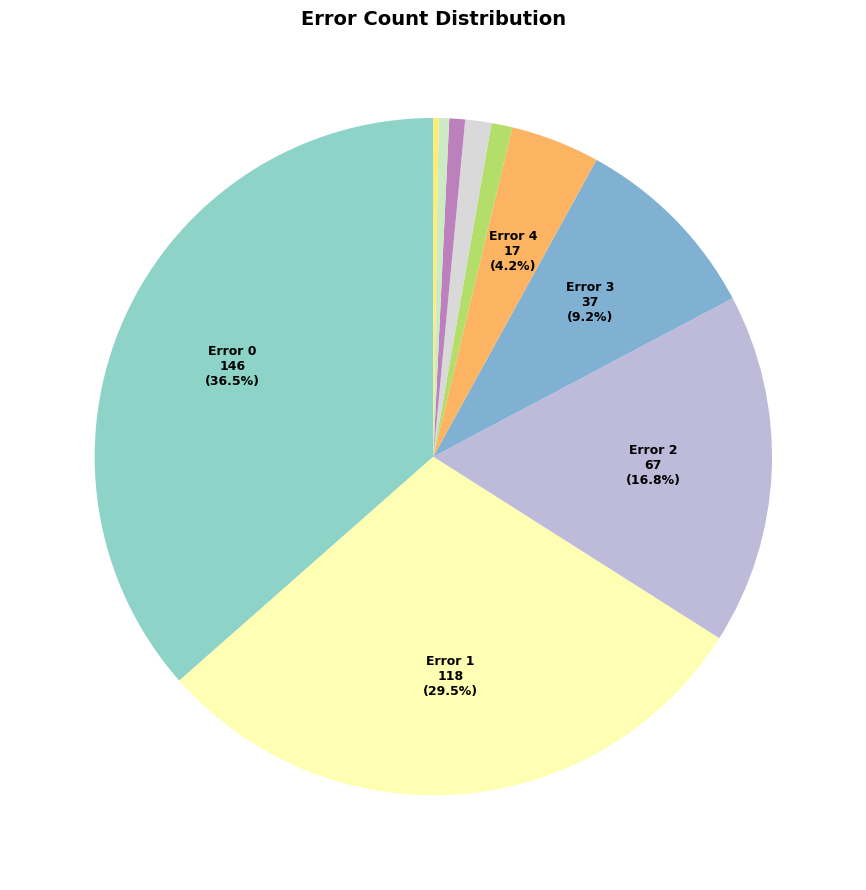

In [ ]:
# 원형 차트 그리기
fig, ax = plt.subplots(figsize=(14, 9))

colors = plt.cm.Set3(np.linspace(0, 1, len(keys)))

# 임계값 설정 (3% 이하는 슬라이스 밖에)
threshold = 3.0

# 슬라이스 생성
wedges, texts = ax.pie(
    values, 
    colors=colors,
    startangle=90,
)

# 슬라이스 안에 텍스트 추가
for i, wedge in enumerate(wedges):
    percentage = (values[i] / sum(values)) * 100
    
    if percentage > threshold:
        # 각도 계산
        angle = (wedge.theta2 + wedge.theta1) / 2
        angle_rad = np.radians(angle)
        
        # 슬라이스 중간 위치에 텍스트 배치
        r = 0.65
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        
        # 슬라이스 안에 텍스트 표시
        label_text = f'Error {keys[i]}\n{values[i]}\n({percentage:.1f}%)'
        ax.text(x, y, label_text, ha='center', va='center',
               fontsize=9, fontweight='bold', color='black')

ax.set_title('Error Count Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

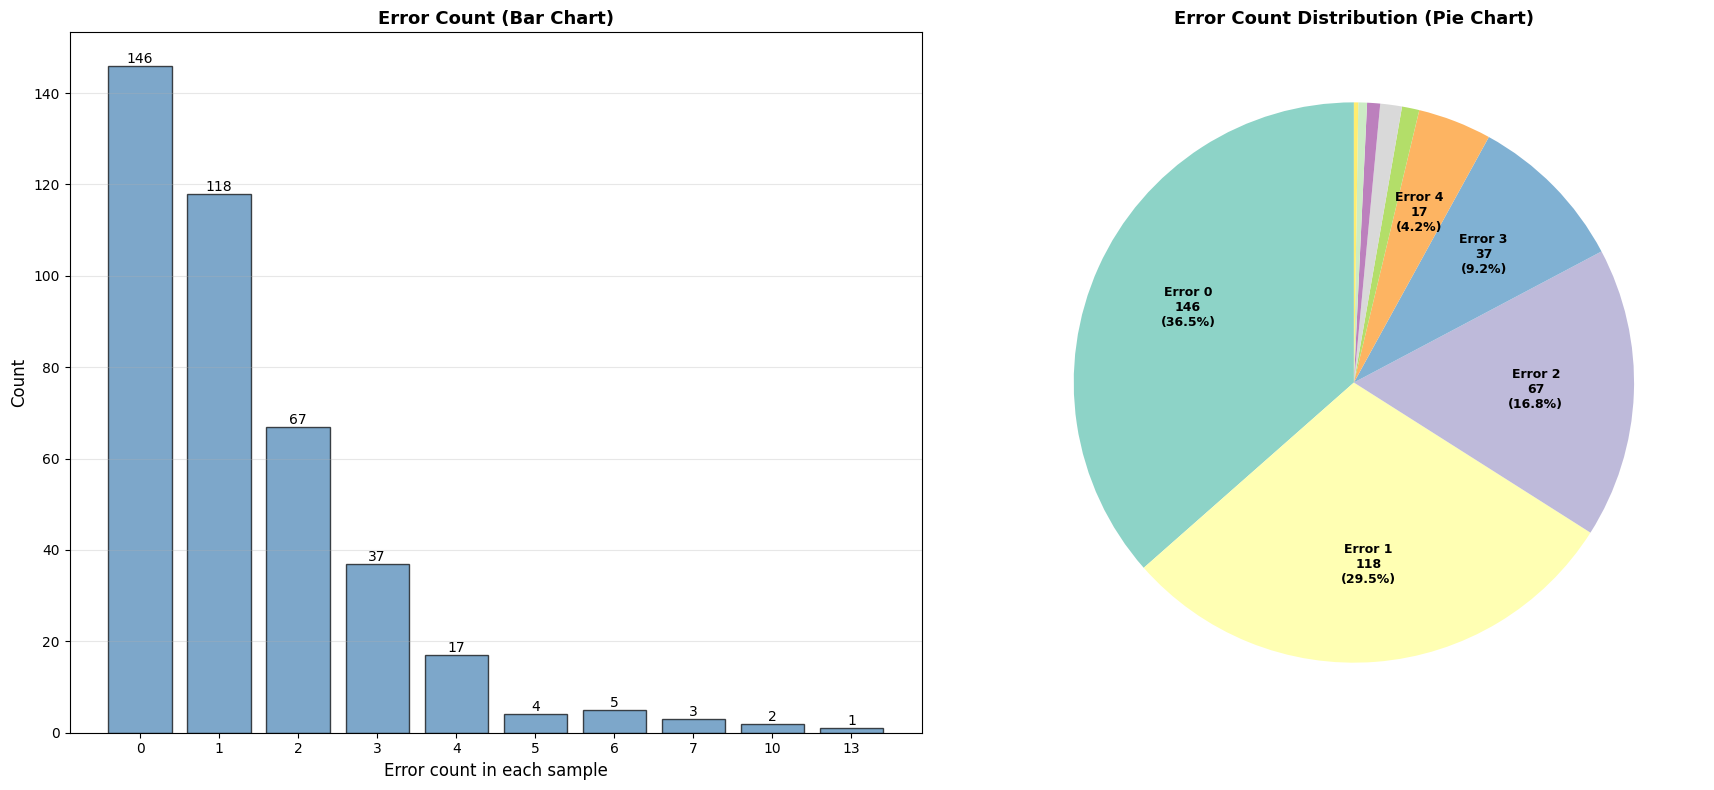

In [33]:
# 히스토그램과 원형 차트를 하나로 합치기
fig = plt.figure(figsize=(18, 8))

# 왼쪽: 히스토그램
ax1 = fig.add_subplot(1, 2, 1)
bars = ax1.bar(keys, values, color='steelblue', edgecolor='black', alpha=0.7)

# 각 바 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

ax1.set_xlabel('Error count in each sample', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Error Count (Bar Chart)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 오른쪽: 원형 차트
ax2 = fig.add_subplot(1, 2, 2)

colors = plt.cm.Set3(np.linspace(0, 1, len(keys)))

# 임계값 설정 (3% 이하는 슬라이스 밖에)
threshold = 3.0

# 슬라이스 생성
wedges, texts = ax2.pie(
    values, 
    colors=colors,
    startangle=90,
)

# 슬라이스 안에 텍스트 추가
for i, wedge in enumerate(wedges):
    percentage = (values[i] / sum(values)) * 100
    
    if percentage > threshold:
        # 각도 계산
        angle = (wedge.theta2 + wedge.theta1) / 2
        angle_rad = np.radians(angle)
        
        # 슬라이스 중간 위치에 텍스트 배치
        r = 0.65
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        
        # 슬라이스 안에 텍스트 표시
        label_text = f'Error {keys[i]}\n{values[i]}\n({percentage:.1f}%)'
        ax2.text(x, y, label_text, ha='center', va='center',
               fontsize=9, fontweight='bold', color='black')

ax2.set_title('Error Count Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()